# 02 – Dimensionsreduktion: Parameter und Nachbarschaften

**Frage:** Wie verändern PCA-, t-SNE- und UMAP-Parameter die zweidimensionale Darstellung derselben Zellen? Wir vergleichen acht vorab festgelegte Karten und messen ihre lokale Nachbarschaftsähnlichkeit.

Wir verwenden `gated_alive`, damit neben NK-Zellen auch andere Immunzellgruppen sichtbar bleiben. Aus jedem der 20 Spender werden genau 500 Zellen ohne Zurücklegen gezogen: insgesamt 10.000 Zellen mit 37 Analysemarkern. Das ist eine spenderbalancierte Stichprobe des großen Gates, kein Lauf auf sämtlichen 3,44 Millionen Events. Seltene Populationen können dadurch fehlen.

**Explorative Ausnahme:** Für Aufgaben 2/3 ist der gemeinsame Fit auf allen 20 Spendern ausdrücklich erlaubt. Die hier gelernte Standardisierung und die Projektionen sind keine Trainingsvorverarbeitung für den Benchmark. Aufgabe 4 bleibt unverändert. Spätere Modell-/Zellscores müssen mit dessen ursprünglichen Modellen und Scalern berechnet werden; die identifizierbaren Koordinaten dürfen lediglich als Darstellung dienen.

In [1]:
from pathlib import Path
import sys
import hashlib
import importlib.metadata as package_metadata
import json
from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "task23_analysis.py").exists())
sys.path.insert(0, str(PROJECT_ROOT))
from src.task23_analysis import (
    load_exploratory_data, projection_configs, fit_projection,
    neighbor_indices, neighbor_jaccard, recommend_projections,
)

TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="white", context="notebook")
versions = {name: package_metadata.version(name) for name in
            ["numpy", "pandas", "scipy", "scikit-learn", "umap-learn", "numba", "flowkit", "matplotlib", "seaborn"]}
display(pd.Series(versions, name="Paketversion"))

numpy            2.5.2
pandas           2.3.3
scipy           1.18.0
scikit-learn     1.9.0
umap-learn      0.5.12
numba           0.67.0
flowkit          1.3.2
matplotlib      3.11.1
seaborn         0.13.2
Name: Paketversion, dtype: object

## 1. Gemeinsame Zellen und Transformation

Spender werden alphabetisch sortiert; Spender Nummer `i` wird mit `default_rng(42 + i)` beprobt. Die Zell-ID enthält Gate, Spender und nullbasierten Original-Eventindex. PnS-Markernamen werden in der Reihenfolge von `NK_markers.csv` ausgewählt; technische Kanäle und CMV-Labels gehen nicht in die Projektionen ein.

Wir übernehmen die projektweit verwendete feste Transformation `arcsinh(x/5)` und standardisieren anschließend jeden Marker über die balancierte Explorationsstichprobe. Das gibt jedem Spender gleiches Gesamtgewicht und verhindert, dass große numerische Markerskalen die euklidischen Distanzen allein bestimmen. Schwach streuende Marker werden dadurch relativ stärker gewichtet; die Standardisierung ist eine dokumentierte methodische Entscheidung. Es erfolgt keine separate Standardisierung pro Spender. Der bekannte FCS-Offsetfehler wird wie in Aufgabe 1 mit `ignore_offset_error=True` behandelt.

In [2]:
cells, transformed, scaled, scaler, provenance = load_exploratory_data(PROJECT_ROOT)
assert cells.cell_id.is_unique
assert len(cells) == 10_000 and scaled.shape == (10_000, 37)
assert cells.groupby("sample_id").size().eq(500).all()
assert np.isfinite(scaled).all()
assert np.allclose(scaled.mean(axis=0), 0, atol=1e-12)
display(cells.groupby("sample_id").size().rename("gezogene Zellen").to_frame().T)
print(f"Eingabe: {scaled.shape[0]:,} Zellen × {scaled.shape[1]} Marker; ausschließlich gated_alive.")

sample_id,a_001,a_002,a_003,a_004,a_005,a_006,a_007,a_009,a_010,a_011,a_012,a_1a,a_2a,a_2b,a_3a,a_3b,a_4a,a_4b,a_5a,a_5b
gezogene Zellen,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500,500


Eingabe: 10,000 Zellen × 37 Marker; ausschließlich gated_alive.


## 2. Parameterwahl und acht Beispielkarten

| Verfahren | Variierte Parameter | Erwarteter Einfluss; weitere wählbare Parameter |
|---|---|---|
| PCA | `whiten=False/True`, zwei Komponenten | Whitening skaliert dieselben Hauptachsen auf Einheitsvarianz; es fügt keine Information hinzu. Komponentenanzahl bestimmt die beibehaltene Dimension; Solver steuert die numerische Berechnung. Wir verwenden den vollständigen deterministischen SVD-Solver. |
| t-SNE | Perplexität 5, 30, 50 | Steuert die effektive lokale Nachbarschaft. Kleine Werte betonen kleinräumige Strukturen, größere beziehen mehr Nachbarn ein. Auch Initialisierung, Lernrate, frühe Übertreibung, Iterationen und Seed können das Ergebnis verändern; sie bleiben hier fest. |
| UMAP | `(n_neighbors, min_dist)` = `(15, 0.1)`, `(50, 0.1)`, `(15, 0.5)` | Mehr Nachbarn beziehen breitere Struktur ein; größere `min_dist` erlauben weniger dicht gepackte Punkte. Distanzmetrik, Initialisierung, Epochen, Seed und Zieldimension sind ebenfalls wählbar und werden konstant gehalten. |

Alle Verfahren erhalten dieselben 37 standardisierten Marker. t-SNE und UMAP verwenden euklidische Distanzen und Seed 42; PCA-Initialisierung von t-SNE reduziert nicht dessen Eingabedaten auf zwei Markerkomponenten. Die explizit festgelegten Einstellungen stehen in der folgenden Tabelle und im Export; übrige Parameter behalten die Defaults der dokumentierten Paketversionen. Die acht Varianten sind eine kleine Sensitivitätsanalyse, keine exhaustive Optimierung und keine exakte Reproduktion einer Abbildung des CellCNN-Papers.

Die Achseneinheiten haben in jedem Panel dasselbe Seitenverhältnis: Sonst könnte automatische Plotstreckung den Whitening-Effekt verdecken. CD3 wird überall mit derselben arcsinh-Farbskala gezeigt; unterschiedliche Zeichenreihenfolgen erzeugen keine scheinbaren Gruppenunterschiede.

In [3]:
configs = projection_configs()
parameter_table = pd.DataFrame([
    {"variant": c["variant"], "method": c["method"],
     "parameters": json.dumps(c["params"], sort_keys=True)} for c in configs
])
display(parameter_table)
embeddings, diagnostics, runtimes = {}, {}, {}
with threadpool_limits(limits=1):
    for config in configs:
        started = perf_counter()
        variant = config["variant"]
        embeddings[variant], diagnostics[variant] = fit_projection(scaled, config)
        runtimes[variant] = perf_counter() - started
        print(f"{variant}: {runtimes[variant]:.1f} s")
print("PCA erklärte Varianz, PC1/PC2:", diagnostics["pca"]["explained_variance_ratio"])

,variant,method,parameters
0,pca,PCA,"{""n_components"": 2, ""svd_solver"": ""full"", ""whi..."
1,pca_white,PCA,"{""n_components"": 2, ""svd_solver"": ""full"", ""whi..."
2,tsne_p5,t-SNE,"{""angle"": 0.5, ""early_exaggeration"": 12, ""init..."
3,tsne_p30,t-SNE,"{""angle"": 0.5, ""early_exaggeration"": 12, ""init..."
4,tsne_p50,t-SNE,"{""angle"": 0.5, ""early_exaggeration"": 12, ""init..."
5,umap_n15_d0.1,UMAP,"{""init"": ""spectral"", ""metric"": ""euclidean"", ""m..."
6,umap_n50_d0.1,UMAP,"{""init"": ""spectral"", ""metric"": ""euclidean"", ""m..."
7,umap_n15_d0.5,UMAP,"{""init"": ""spectral"", ""metric"": ""euclidean"", ""m..."


pca: 0.0 s
pca_white: 0.0 s


tsne_p5: 29.0 s


tsne_p30: 32.7 s


tsne_p50: 37.4 s


/home/gregor/projects/Group-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


umap_n15_d0.1: 17.8 s


umap_n50_d0.1: 11.6 s


umap_n15_d0.5: 6.7 s
PCA erklärte Varianz, PC1/PC2: [0.16086432715326815, 0.10308333559249251]


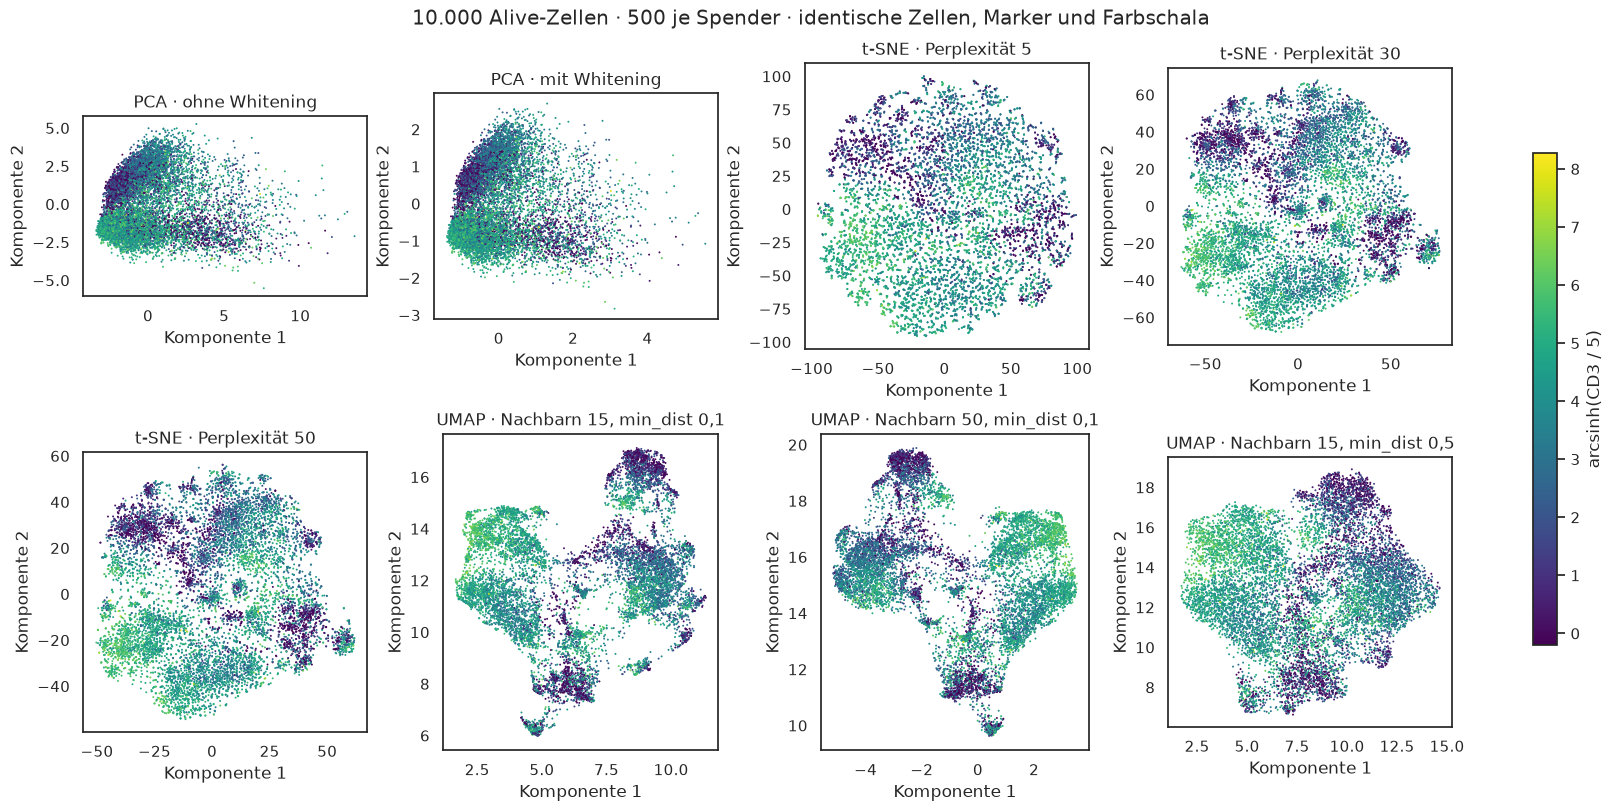

In [4]:
titles = {
    "pca": "PCA · ohne Whitening", "pca_white": "PCA · mit Whitening",
    "tsne_p5": "t-SNE · Perplexität 5", "tsne_p30": "t-SNE · Perplexität 30",
    "tsne_p50": "t-SNE · Perplexität 50", "umap_n15_d0.1": "UMAP · Nachbarn 15, min_dist 0,1",
    "umap_n50_d0.1": "UMAP · Nachbarn 50, min_dist 0,1", "umap_n15_d0.5": "UMAP · Nachbarn 15, min_dist 0,5",
}
color_values = transformed["CD3"].to_numpy()
color_norm = Normalize(vmin=color_values.min(), vmax=color_values.max())
plot_order = np.random.default_rng(42).permutation(len(cells))
fig, axes = plt.subplots(2, 4, figsize=(16, 8), layout="constrained")
for axis, config in zip(axes.flat, configs):
    variant = config["variant"]
    coordinates = embeddings[variant][plot_order]
    scatter = axis.scatter(*coordinates.T, c=color_values[plot_order], cmap="viridis",
                           norm=color_norm, s=2, linewidths=0, rasterized=True)
    axis.set(title=titles[variant], xlabel="Komponente 1", ylabel="Komponente 2", aspect="equal")
fig.colorbar(scatter, ax=axes.ravel().tolist(), label="arcsinh(CD3 / 5)", shrink=0.7)
fig.suptitle("10.000 Alive-Zellen · 500 je Spender · identische Zellen, Marker und Farbschala")
fig.savefig(FIGURE_DIR / "task2_projection_grid.png", dpi=180)
plt.show()

## 3. Alle Kartenpaare quantitativ vergleichen

Mögliche Maße wären Prokrustes-Distanzen nach Ausrichtung, Rangkorrelationen der paarweisen Abstände oder Überlappungen lokaler Nachbarschaften. Wir wählen die **15-Nachbarn-Jaccard-Ähnlichkeit**, da sie auf identifizierbaren Zellen beruht und weder gleiche Achsenorientierung noch gleiche Koordinatenskala voraussetzt.

Für Zelle $i$ und zwei Karten $A,B$ gilt $J_i=|N_{15}^{A}(i)\cap N_{15}^{B}(i)|/|N_{15}^{A}(i)\cup N_{15}^{B}(i)|$. Die eigene Zell-ID wird ausgeschlossen, auch bei identischen Koordinaten. Wir mitteln zunächst über die 500 Zellen jedes Spenders und anschließend gleich gewichtet über die 20 Spender. 1 bedeutet identische, 0 disjunkte Nachbarschaften. Distanzgleichstände folgen der Bibliotheksreihenfolge; Zellreihenfolge und Paketversionen sind festgehalten.

Das Maß erfasst lokale Übereinstimmung, keine vollständige globale Geometrie und keine biologische Wahrheit. Zusätzlich vergleichen wir jede Karte mit den 15 nächsten Nachbarn im standardisierten 37D-Eingaberaum. Diese Referenz ist unsere gewählte Metrik des **Nachbarschaftserhalts**, keine unabhängige Validierung. Die 28 ungeordneten Kartenpaare werden vollständig ausgewertet.

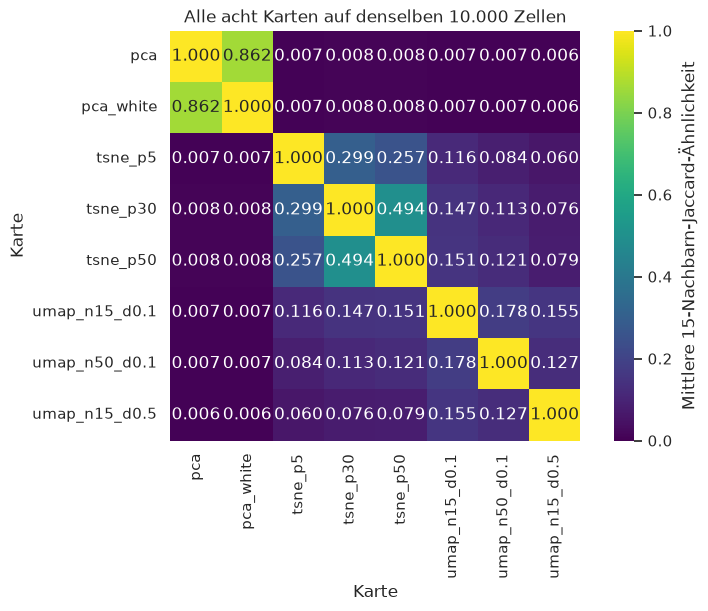

,method,variant,reference_jaccard
0,PCA,pca,0.0102
1,PCA,pca_white,0.0102
2,t-SNE,tsne_p5,0.1621
3,t-SNE,tsne_p30,0.1824
4,t-SNE,tsne_p50,0.1798
5,UMAP,umap_n15_d0.1,0.0917
6,UMAP,umap_n50_d0.1,0.0738
7,UMAP,umap_n15_d0.5,0.0531


In [5]:
with threadpool_limits(limits=1):
    neighbors = {variant: neighbor_indices(coordinates, k=15)
                 for variant, coordinates in embeddings.items()}
    reference_neighbors = neighbor_indices(scaled, k=15)
variant_names = list(embeddings)
pairwise = pd.DataFrame(np.eye(len(variant_names)), index=variant_names, columns=variant_names)
pair_rows = []
for first, second in combinations(variant_names, 2):
    score = neighbor_jaccard(neighbors[first], neighbors[second], cells.sample_id)
    pairwise.loc[first, second] = pairwise.loc[second, first] = score
    pair_rows.append({"first": first, "second": second, "neighbor_jaccard": score})
pair_scores = pd.DataFrame(pair_rows)
summary = pd.DataFrame([
    {"method": config["method"], "variant": config["variant"],
     "reference_jaccard": neighbor_jaccard(neighbors[config["variant"]], reference_neighbors, cells.sample_id),
     "fit_seconds": runtimes[config["variant"]]} for config in configs
])
assert len(pair_scores) == 28
assert np.allclose(pairwise, pairwise.T) and np.allclose(np.diag(pairwise), 1)
assert pairwise.to_numpy().min() >= 0 and pairwise.to_numpy().max() <= 1
fig, axis = plt.subplots(figsize=(8, 6), layout="constrained")
sns.heatmap(pairwise, annot=True, fmt=".3f", vmin=0, vmax=1, cmap="viridis", square=True,
            cbar_kws={"label": "Mittlere 15-Nachbarn-Jaccard-Ähnlichkeit"}, ax=axis)
axis.set(title="Alle acht Karten auf denselben 10.000 Zellen", xlabel="Karte", ylabel="Karte")
fig.savefig(FIGURE_DIR / "task2_neighbor_agreement.png", dpi=180)
plt.show()
display(summary.drop(columns="fit_seconds").round(4))

## 4. Empfehlung innerhalb des untersuchten Rasters

Wir empfehlen je Verfahren die Variante mit höchstem 37D-Nachbarschaftserhalt. Bei numerischen Gleichständen (`atol=1e-12`, `rtol=0`) bevorzugen wir die Baseline: PCA ohne Whitening, t-SNE mit Perplexität 30 beziehungsweise UMAP mit 15 Nachbarn und `min_dist=0.1`; danach entscheidet die vorab festgelegte Rasterreihenfolge. Das ist eine nachvollziehbare lokale Empfehlung **für diese Stichprobe und k=15**, kein global optimaler Parameter und keine Aussage über bessere Klassifikationsleistung.

Bei t-SNE/UMAP dürfen Entfernungen zwischen Inseln und deren gezeichnete Flächen nicht unmittelbar als biologische Distanzen beziehungsweise Häufigkeiten gelesen werden. Auch visuell saubere CD3-Gruppen ersetzen keine Markerprofilanalyse; diese folgt in Aufgabe 3.

**Leseschlüssel der Varianten:** `pca` bedeutet PCA ohne Whitening, `pca_white` mit Whitening; `tsne_p30` bedeutet beispielsweise Perplexität 30. `umap_n15_d0.1` bezeichnet 15 Nachbarn und `min_dist=0.1` (entsprechend gelten `n50` und `d0.5`).

In [6]:
recommendations = recommend_projections(summary)
display(recommendations.rename(columns={"method": "Verfahren", "variant": "Empfohlene Variante",
                                       "reference_jaccard": "37D-Jaccard", "reason": "Begründung"}))
strongest = pair_scores.loc[pair_scores.neighbor_jaccard.idxmax()]
weakest = pair_scores.loc[pair_scores.neighbor_jaccard.idxmin()]
variance = sum(diagnostics["pca"]["explained_variance_ratio"])
conclusions = [f"Die ersten beiden Hauptkomponenten erklären zusammen **{variance:.1%}** der standardisierten Markervarianz."]
for row in recommendations.itertuples():
    conclusions.append(f"Für **{row.method}** erhält `{row.variant}` im untersuchten Raster die höchste lokale Referenzübereinstimmung: **J = {row.reference_jaccard:.4f}**.")
conclusions.append(f"Die höchste Kartenübereinstimmung liegt zwischen `{strongest['first']}` und `{strongest['second']}` (J = {strongest.neighbor_jaccard:.4f}), die niedrigste zwischen `{weakest['first']}` und `{weakest['second']}` (J = {weakest.neighbor_jaccard:.4f}).")
display(Markdown("\n\n".join(conclusions)))

,Verfahren,Empfohlene Variante,37D-Jaccard,Begründung
0,PCA,pca,0.010209,Höchster 37D-Nachbarschaftserhalt im untersuch...
1,t-SNE,tsne_p30,0.182366,Höchster 37D-Nachbarschaftserhalt im untersuch...
2,UMAP,umap_n15_d0.1,0.091712,Höchster 37D-Nachbarschaftserhalt im untersuch...


Die ersten beiden Hauptkomponenten erklären zusammen **26.4%** der standardisierten Markervarianz.

Für **PCA** erhält `pca` im untersuchten Raster die höchste lokale Referenzübereinstimmung: **J = 0.0102**.

Für **t-SNE** erhält `tsne_p30` im untersuchten Raster die höchste lokale Referenzübereinstimmung: **J = 0.1824**.

Für **UMAP** erhält `umap_n15_d0.1` im untersuchten Raster die höchste lokale Referenzübereinstimmung: **J = 0.0917**.

Die höchste Kartenübereinstimmung liegt zwischen `pca` und `pca_white` (J = 0.8618), die niedrigste zwischen `pca_white` und `umap_n15_d0.5` (J = 0.0064).

**Beobachtung der Beispielkarten:** Bei t-SNE mit Perplexität 5 wirkt die Darstellung stärker in kleine lokale Gruppen aufgeteilt; bei 30 und 50 werden größere zusammenhängende Bereiche sichtbar. Der lokale Referenzerhalt steigt von 5 auf 30 und sinkt bei 50 leicht: Größere Perplexität ist hier also nicht durchgehend besser. UMAP mit `min_dist=0.5` zeigt weniger dicht gepackte Bereiche als die Baseline. Sowohl mehr UMAP-Nachbarn als auch größere `min_dist` vermindern hier den gemessenen Erhalt der 15 nächsten Nachbarn. Das spricht für die Baseline unter diesem lokalen Kriterium, nicht gegen den möglichen Nutzen breiterer Struktur in anderen Fragestellungen. Die beiden PCA-Karten zeigen dieselbe grobe Struktur; ihr geringer 37D-Jaccard unterstreicht den Informationsverlust bei der Beschränkung auf zwei Achsen.

**PCA praktisch gleichwertig:** Der 37D-Jaccard beträgt ohne Whitening 0,0102088 und mit Whitening 0,0102011. Die Differenz von rund 0,0000077 ist praktisch vernachlässigbar. Die formale Empfehlung ohne Whitening folgt dem festgelegten Auswahlkriterium; daraus ergibt sich kein inhaltlich relevanter Vorteil.

## 5. Reproduzierbare, begrenzte Exporte

Zell-IDs, vollständige Koordinaten, alle Paarwerte und Parameter werden exportiert. Die Provenienz enthält Stichprobenprüfsumme, Markerreihenfolge, Scaler, Fitdiagnosen und Paketversionen. Ein erneutes `Run All` berechnet diese Analyse neu. Aufgabe 3 lädt seine Zellen eigenständig und verwendet denselben Code für die Basiskarte; es benötigt weder Kernelzustand noch möglicherweise veraltete Aufgabe-2-Dateien.

Für den insgesamt fünfseitigen Bericht sind nur wenige repräsentative Panels und eine kleine Vergleichstabelle aus Aufgaben 2/3 vorgesehen. Die vollständige Parametersensitivität bleibt hier nachvollziehbar.

In [7]:
coordinates_table = pd.concat([
    cells.assign(variant=variant, component_1=coordinates[:, 0], component_2=coordinates[:, 1])
    for variant, coordinates in embeddings.items()
], ignore_index=True)
cells.to_csv(TABLE_DIR / "task2_cells.csv", index=False)
coordinates_table.to_csv(TABLE_DIR / "task2_embeddings.csv", index=False)
parameter_table.to_csv(TABLE_DIR / "task2_parameters.csv", index=False)
pair_scores.to_csv(TABLE_DIR / "task2_pairwise_jaccard.csv", index=False)
summary.to_csv(TABLE_DIR / "task2_reference_jaccard.csv", index=False)
recommendations.to_csv(TABLE_DIR / "task2_recommendations.csv", index=False)
provenance.update(configurations=configs, versions=versions, diagnostics=diagnostics,
                  comparison_neighbors=15, aggregation="cell mean per donor, then equal donor mean",
                  thread_limit=1, implementation_sha256=hashlib.sha256(
                      (PROJECT_ROOT / "src" / "task23_analysis.py").read_bytes()).hexdigest())
(TABLE_DIR / "task2_provenance.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")
print("Exportiert: Zellmetadaten, acht Karten, 28 Paarwerte, Referenzwerte, Empfehlungen, Parameter und Provenienz.")

Exportiert: Zellmetadaten, acht Karten, 28 Paarwerte, Referenzwerte, Empfehlungen, Parameter und Provenienz.


## Quellen

- [Arvaniti & Claassen (2017), CellCNN](https://doi.org/10.1038/ncomms14825): Kontext des Projekts und Datensatz; die hier untersuchte Dimensionsreduktion ist eine eigene explorative Ergänzung.
- [scikit-learn: PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html): Komponenten, Solver und Whitening.
- [scikit-learn: t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html): Perplexität und Optimierungsparameter.
- [UMAP: Grundparameter](https://umap-learn.readthedocs.io/en/latest/parameters.html): Nachbarzahl, `min_dist` und Metrik.